In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

processed_dir = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(processed_dir / "X_train.csv")
X_val = pd.read_csv(processed_dir / "X_val.csv")

y_train = pd.read_csv(
    processed_dir / "y_train.csv"
).squeeze("columns")

y_val = pd.read_csv(
    processed_dir / "y_val.csv"
).squeeze("columns")

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (177576, 21)
Validation: (38052, 21)


In [3]:
best_hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=400,
    max_leaf_nodes=31,
    max_depth=5,
    min_samples_leaf=50,
    l2_regularization=0.5,
    random_state=42
)

best_hgb.fit(X_train, y_train)

print("Base HGB trained successfully.")

Base HGB trained successfully.


In [4]:
raw_probabilities = best_hgb.predict_proba(X_val)[:, 1]

print("Raw ROC-AUC:", round(
    roc_auc_score(y_val, raw_probabilities), 4
))

print("Raw PR-AUC:", round(
    average_precision_score(y_val, raw_probabilities), 4
))

print("Raw Brier Score:", round(
    brier_score_loss(y_val, raw_probabilities), 4
))

Raw ROC-AUC: 0.8287
Raw PR-AUC: 0.427
Raw Brier Score: 0.097


In [5]:
sigmoid_calibrator = CalibratedClassifierCV(
    best_hgb,
    method="sigmoid",
)

sigmoid_calibrator.fit(
    X_val,
    y_val
)

sigmoid_probabilities = sigmoid_calibrator.predict_proba(
    X_val
)[:, 1]

print("Sigmoid ROC-AUC:", round(
    roc_auc_score(y_val, sigmoid_probabilities), 4
))

print("Sigmoid PR-AUC:", round(
    average_precision_score(y_val, sigmoid_probabilities), 4
))

print("Sigmoid Brier Score:", round(
    brier_score_loss(y_val, sigmoid_probabilities), 4
))

Sigmoid ROC-AUC: 0.8441
Sigmoid PR-AUC: 0.4643
Sigmoid Brier Score: 0.0939


In [6]:
isotonic_calibrator = CalibratedClassifierCV(
    best_hgb,
    method="isotonic",
)

isotonic_calibrator.fit(
    X_val,
    y_val
)

isotonic_probabilities = isotonic_calibrator.predict_proba(
    X_val
)[:, 1]

print("Isotonic ROC-AUC:", round(
    roc_auc_score(y_val, isotonic_probabilities), 4
))

print("Isotonic PR-AUC:", round(
    average_precision_score(y_val, isotonic_probabilities), 4
))

print("Isotonic Brier Score:", round(
    brier_score_loss(y_val, isotonic_probabilities), 4
))

Isotonic ROC-AUC: 0.8446
Isotonic PR-AUC: 0.4657
Isotonic Brier Score: 0.0938


In [7]:
calibration_results = pd.DataFrame([
    {
        "Model": "Raw HGB",
        "ROC-AUC": roc_auc_score(y_val, raw_probabilities),
        "PR-AUC": average_precision_score(y_val, raw_probabilities),
        "Brier Score": brier_score_loss(y_val, raw_probabilities)
    },
    {
        "Model": "Sigmoid Calibration",
        "ROC-AUC": roc_auc_score(y_val, sigmoid_probabilities),
        "PR-AUC": average_precision_score(y_val, sigmoid_probabilities),
        "Brier Score": brier_score_loss(y_val, sigmoid_probabilities)
    },
    {
        "Model": "Isotonic Calibration",
        "ROC-AUC": roc_auc_score(y_val, isotonic_probabilities),
        "PR-AUC": average_precision_score(y_val, isotonic_probabilities),
        "Brier Score": brier_score_loss(y_val, isotonic_probabilities)
    }
])

calibration_results.round(4)

,Model,ROC-AUC,PR-AUC,Brier Score
0,Raw HGB,0.8287,0.4270,0.0970
1,Sigmoid Calibration,0.8441,0.4643,0.0939
2,Isotonic Calibration,0.8446,0.4657,0.0938


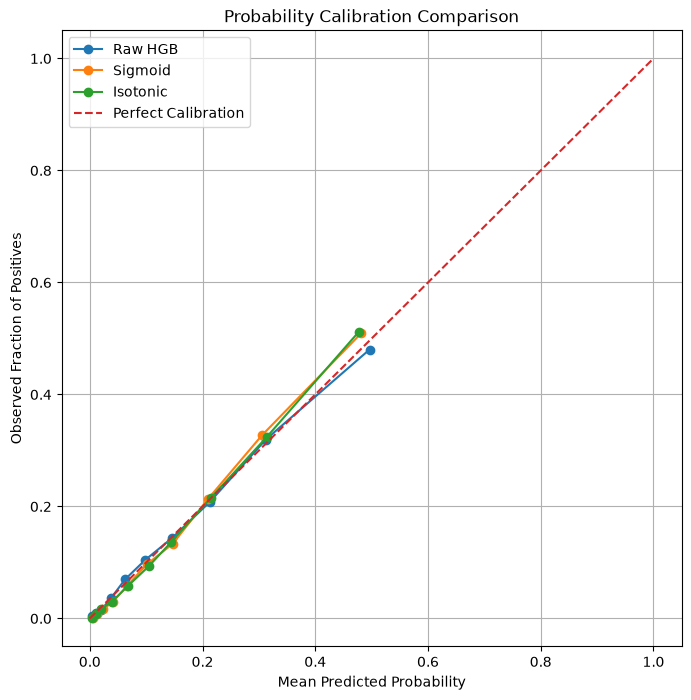

In [8]:
plt.figure(figsize=(8, 8))

models_to_plot = {
    "Raw HGB": raw_probabilities,
    "Sigmoid": sigmoid_probabilities,
    "Isotonic": isotonic_probabilities
}

for name, probabilities in models_to_plot.items():

    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_val,
        probabilities,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positives")
plt.title("Probability Calibration Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [9]:
best_calibration = calibration_results.loc[
    calibration_results["Brier Score"].idxmin()
]

best_calibration

Model          Isotonic Calibration
ROC-AUC                    0.844595
PR-AUC                     0.465667
Brier Score                0.093826
Name: 2, dtype: object

In [10]:
X_train_val = pd.concat(
    [X_train, X_val],
    ignore_index=True
)

y_train_val = pd.concat(
    [y_train, y_val],
    ignore_index=True
)

print(X_train_val.shape)
print(y_train_val.shape)

(215628, 21)
(215628,)


In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

final_hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=400,
    max_leaf_nodes=31,
    max_depth=5,
    min_samples_leaf=50,
    l2_regularization=0.5,
    random_state=42
)

In [12]:
final_calibrated_model = CalibratedClassifierCV(
    estimator=final_hgb,
    method="isotonic",
    cv=5
)

In [13]:
final_calibrated_model.fit(
    X_train_val,
    y_train_val
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",HistGradientB...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0028E4F9D58B0>, <s

In [14]:
import pandas as pd

X_train_val = pd.concat(
    [X_train, X_val],
    axis=0,
    ignore_index=True
)

y_train_val = pd.concat(
    [y_train, y_val],
    axis=0,
    ignore_index=True
)

print("X_train_val shape:", X_train_val.shape)
print("y_train_val shape:", y_train_val.shape)

X_train_val shape: (215628, 21)
y_train_val shape: (215628,)


In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

final_hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=400,
    max_leaf_nodes=31,
    max_depth=5,
    min_samples_leaf=50,
    l2_regularization=0.5,
    random_state=42
)

final_calibrated_model = CalibratedClassifierCV(
    estimator=final_hgb,
    method="isotonic",
    cv=5
)

final_calibrated_model.fit(
    X_train_val,
    y_train_val
)

print("Final calibrated model trained successfully!")

Final calibrated model trained successfully!


In [16]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

processed_dir = PROJECT_ROOT / "data" / "processed"

X_test = pd.read_csv(processed_dir / "X_test.csv")

y_test = pd.read_csv(
    processed_dir / "y_test.csv"
).squeeze("columns")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (38052, 21)
y_test shape: (38052,)


In [17]:
print(X_train.shape)
print(X_val.shape)

(177576, 21)
(38052, 21)


In [18]:
print(X_test.columns.tolist())
print("Number of features:", X_test.shape[1])

['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Number of features: 21


In [19]:
y_test_proba = final_calibrated_model.predict_proba(X_test)[:, 1]

print("Number of test predictions:", len(y_test_proba))
print("Minimum probability:", y_test_proba.min())
print("Maximum probability:", y_test_proba.max())
print("Average probability:", y_test_proba.mean())

Number of test predictions: 38052
Minimum probability: 0.0
Maximum probability: 0.9932155318890956
Average probability: 0.13841272491554493


In [20]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

test_roc_auc = roc_auc_score(y_test, y_test_proba)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

test_brier = brier_score_loss(
    y_test,
    y_test_proba
)

print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC: {test_pr_auc:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")

Test ROC-AUC: 0.8297
Test PR-AUC: 0.4300
Test Brier Score: 0.0968


In [21]:
print(list(processed_dir.iterdir()))

[WindowsPath('c:/Users/dell/Desktop/Personal projects/Hackathon Project/Machine_Learning_Model/data/processed/X_test.csv'), WindowsPath('c:/Users/dell/Desktop/Personal projects/Hackathon Project/Machine_Learning_Model/data/processed/X_train.csv'), WindowsPath('c:/Users/dell/Desktop/Personal projects/Hackathon Project/Machine_Learning_Model/data/processed/X_val.csv'), WindowsPath('c:/Users/dell/Desktop/Personal projects/Hackathon Project/Machine_Learning_Model/data/processed/y_test.csv'), WindowsPath('c:/Users/dell/Desktop/Personal projects/Hackathon Project/Machine_Learning_Model/data/processed/y_train.csv'), WindowsPath('c:/Users/dell/Desktop/Personal projects/Hackathon Project/Machine_Learning_Model/data/processed/y_val.csv')]


In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = np.arange(0.10, 0.71, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_test_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sort_values(
    by="F1 Score",
    ascending=False
).head(15)

,Threshold,Precision,Recall,F1 Score,Accuracy
14,0.24,0.389973,0.595624,0.471343,0.813834
11,0.21,0.372124,0.640513,0.470751,0.799327
13,0.23,0.384523,0.606375,0.470614,0.809918
15,0.25,0.394855,0.581856,0.470454,0.817487
12,0.22,0.378565,0.620898,0.470353,0.805161
10,0.20,0.362941,0.662014,0.468844,0.790997
16,0.26,0.399574,0.565824,0.468384,0.821034
17,0.27,0.406481,0.548849,0.467057,0.825476
9,0.19,0.351390,0.691249,0.465929,0.779197
8,0.18,0.343100,0.715579,0.463814,0.769473


In [23]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold_row

Threshold    0.240000
Precision    0.389973
Recall       0.595624
F1 Score     0.471343
Accuracy     0.813834
Name: 14, dtype: float64

In [24]:
FINAL_THRESHOLD = 0.24

In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

FINAL_THRESHOLD = 0.24

y_test_pred = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Diabetes", "Diabetes"]
    )
)

Confusion Matrix:
[[27810  4940]
 [ 2144  3158]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.93      0.85      0.89     32750
    Diabetes       0.39      0.60      0.47      5302

    accuracy                           0.81     38052
   macro avg       0.66      0.72      0.68     38052
weighted avg       0.85      0.81      0.83     38052



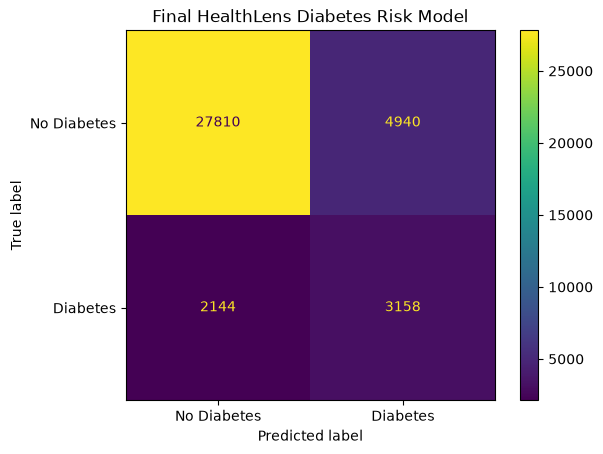

In [26]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Final HealthLens Diabetes Risk Model")
plt.show()

In [27]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


c:\Users\dell\Desktop\Personal projects\Hackathon Project\Machine_Learning_Model\.venv\Scripts\python.exe: No module named pip


In [28]:
import shap
import numpy as np
import pandas as pd

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [29]:
print(type(final_calibrated_model))

print("\nNumber of calibrated classifiers:")
print(len(final_calibrated_model.calibrated_classifiers_))

print("\nFirst calibrated classifier:")
print(final_calibrated_model.calibrated_classifiers_[0])

<class 'sklearn.calibration.CalibratedClassifierCV'>

Number of calibrated classifiers:
5

First calibrated classifier:


In [31]:
calibrated_clf = final_calibrated_model.calibrated_classifiers_[0]

print(type(calibrated_clf))

print("\nAvailable attributes:")
print([attr for attr in dir(calibrated_clf) if not attr.startswith("_")])

<class 'sklearn.calibration._CalibratedClassifier'>

Available attributes:
['calibrators', 'classes', 'estimator', 'method', 'predict_proba']


In [32]:
for i, clf in enumerate(final_calibrated_model.calibrated_classifiers_):
    print(f"Classifier {i}:")
    print(type(clf.estimator))
    print(clf.estimator)
    print("-" * 50)

Classifier 0:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
HistGradientBoostingClassifier(l2_regularization=0.5, learning_rate=0.05,
                               max_depth=5, max_iter=400, min_samples_leaf=50,
                               random_state=42)
--------------------------------------------------
Classifier 1:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
HistGradientBoostingClassifier(l2_regularization=0.5, learning_rate=0.05,
                               max_depth=5, max_iter=400, min_samples_leaf=50,
                               random_state=42)
--------------------------------------------------
Classifier 2:
<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
HistGradientBoostingClassifier(l2_regularization=0.5, learning_rate=0.05,
                               max_depth=5, max_iter=400, min_samples_leaf=50,
 

In [33]:
base_model = final_calibrated_model.calibrated_classifiers_[0].estimator

print(type(base_model))

<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>


In [34]:
X_shap = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 21)


In [35]:
import shap

explainer = shap.TreeExplainer(base_model)

shap_values = explainer(X_shap)

print("SHAP values calculated successfully!")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully!
SHAP values shape: (1000, 21)


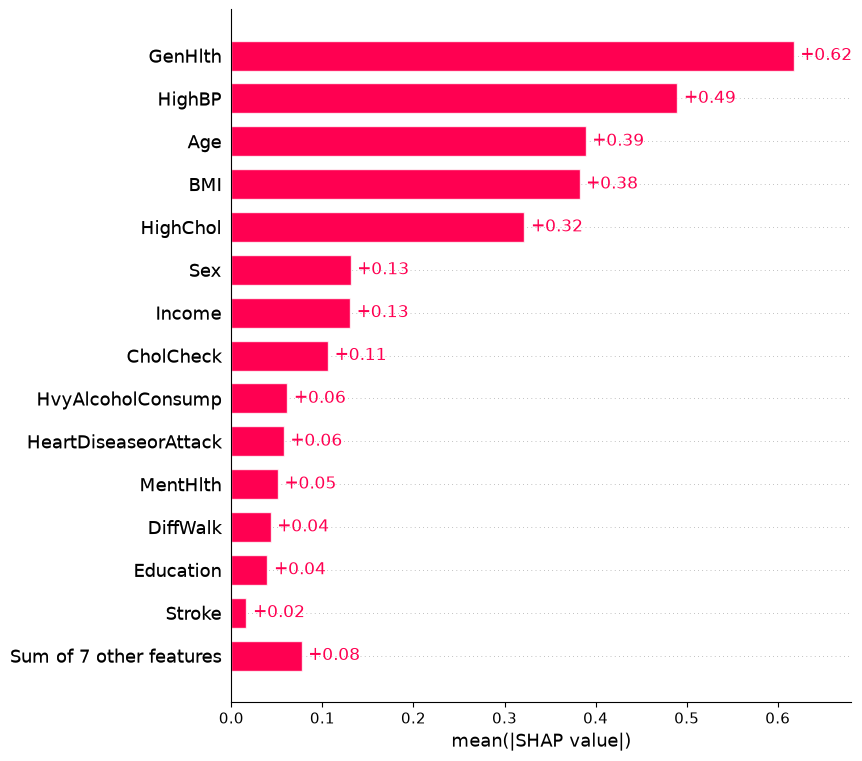

In [36]:
shap.plots.bar(shap_values, max_display=15)

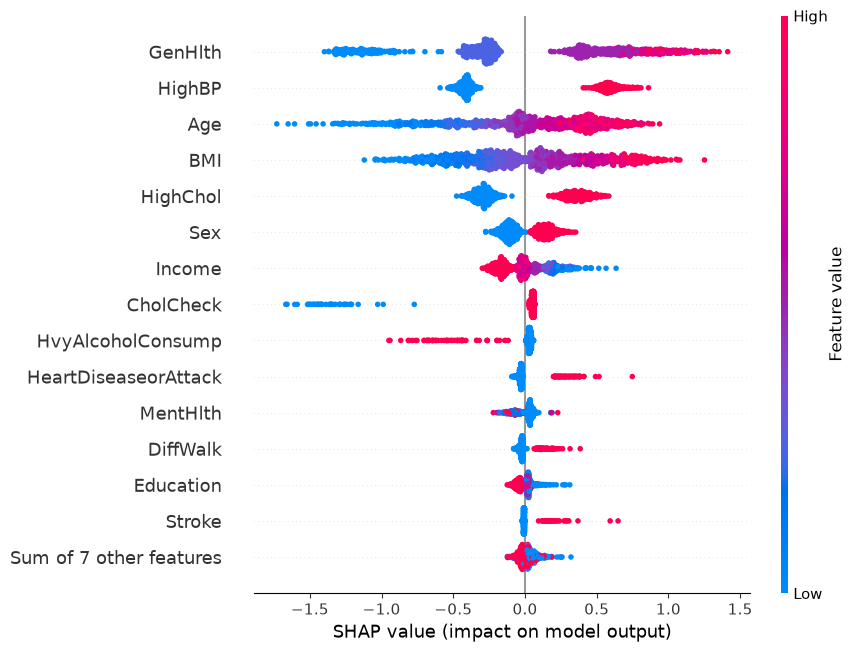

In [37]:
shap.plots.beeswarm(shap_values, max_display=15)

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values.values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Mean_Absolute_SHAP
0,GenHlth,0.617492
1,HighBP,0.489789
2,Age,0.389079
3,BMI,0.382353
4,HighChol,0.321899
5,Sex,0.130966
6,Income,0.130472
7,CholCheck,0.106260
8,HvyAlcoholConsump,0.061532
9,HeartDiseaseorAttack,0.057593


In [39]:
top_features = feature_importance.head(10)

print(top_features)

                Feature  Mean_Absolute_SHAP
0               GenHlth            0.617492
1                HighBP            0.489789
2                   Age            0.389079
3                   BMI            0.382353
4              HighChol            0.321899
5                   Sex            0.130966
6                Income            0.130472
7             CholCheck            0.106260
8     HvyAlcoholConsump            0.061532
9  HeartDiseaseorAttack            0.057593


In [40]:
from pathlib import Path

results_path = Path("../results")
results_path.mkdir(exist_ok=True)

feature_importance.to_csv(
    results_path / "shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully!")

SHAP feature importance saved successfully!


In [41]:
# Select one test user
user_index = 0

X_user = X_test.iloc[[user_index]]

# Get calibrated probability
user_probability = final_calibrated_model.predict_proba(
    X_user
)[:, 1][0]

print("User probability:", user_probability)
print(f"Risk percentage: {user_probability * 100:.2f}%")

# Get SHAP explanation from the base HGB model
user_shap = explainer(X_user)

print("SHAP values shape:", user_shap.values.shape)

User probability: 0.1890630533294455
Risk percentage: 18.91%
SHAP values shape: (1, 21)


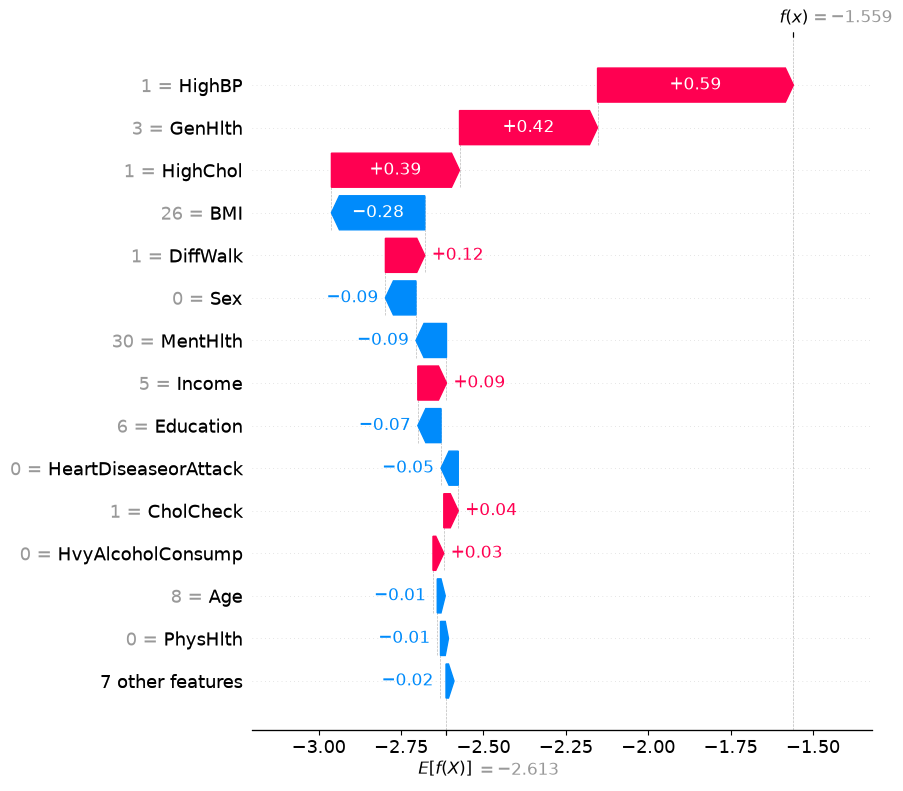

In [42]:
shap.plots.waterfall(
    user_shap[0],
    max_display=15
)

In [43]:
user_values = user_shap.values[0]

user_explanation = pd.DataFrame({
    "Feature": X_user.columns,
    "Feature_Value": X_user.iloc[0].values,
    "SHAP_Value": user_values
})

# Absolute impact
user_explanation["Absolute_Impact"] = (
    user_explanation["SHAP_Value"].abs()
)

user_explanation = user_explanation.sort_values(
    "Absolute_Impact",
    ascending=False
)

user_explanation.head(10)

,Feature,Feature_Value,SHAP_Value,Absolute_Impact
0,HighBP,1.0,0.594397,0.594397
13,GenHlth,3.0,0.418889,0.418889
1,HighChol,1.0,0.388728,0.388728
3,BMI,26.0,-0.283411,0.283411
16,DiffWalk,1.0,0.119591,0.119591
17,Sex,0.0,-0.092839,0.092839
14,MentHlth,30.0,-0.092566,0.092566
20,Income,5.0,0.087043,0.087043
19,Education,6.0,-0.070531,0.070531
6,HeartDiseaseorAttack,0.0,-0.052304,0.052304


In [44]:
risk_factors = user_explanation[
    user_explanation["SHAP_Value"] > 0
].head(5)

protective_factors = user_explanation[
    user_explanation["SHAP_Value"] < 0
].head(5)

print("Factors increasing predicted risk:")
print(risk_factors[
    ["Feature", "Feature_Value", "SHAP_Value"]
])

print("\nFactors decreasing predicted risk:")
print(protective_factors[
    ["Feature", "Feature_Value", "SHAP_Value"]
])

Factors increasing predicted risk:
     Feature  Feature_Value  SHAP_Value
0     HighBP            1.0    0.594397
13   GenHlth            3.0    0.418889
1   HighChol            1.0    0.388728
16  DiffWalk            1.0    0.119591
20    Income            5.0    0.087043

Factors decreasing predicted risk:
                 Feature  Feature_Value  SHAP_Value
3                    BMI           26.0   -0.283411
17                   Sex            0.0   -0.092839
14              MentHlth           30.0   -0.092566
19             Education            6.0   -0.070531
6   HeartDiseaseorAttack            0.0   -0.052304


In [45]:
FEATURE_NAMES = {
    "HighBP": "High blood pressure",
    "HighChol": "High cholesterol",
    "CholCheck": "Cholesterol check",
    "BMI": "Body Mass Index (BMI)",
    "Smoker": "Smoking status",
    "Stroke": "History of stroke",
    "HeartDiseaseorAttack": "Heart disease or heart attack history",
    "PhysActivity": "Physical activity",
    "Fruits": "Fruit consumption",
    "Veggies": "Vegetable consumption",
    "HvyAlcoholConsump": "Heavy alcohol consumption",
    "AnyHealthcare": "Access to healthcare",
    "NoDocbcCost": "Unable to see a doctor because of cost",
    "GenHlth": "Self-reported general health",
    "MentHlth": "Mental health",
    "PhysHlth": "Physical health",
    "DiffWalk": "Difficulty walking",
    "Sex": "Sex",
    "Age": "Age group",
    "Education": "Education level",
    "Income": "Income level"
}

In [46]:
USER_FACING_FEATURES = [
    "HighBP",
    "HighChol",
    "BMI",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "HvyAlcoholConsump",
    "GenHlth",
    "PhysHlth",
    "DiffWalk",
    "Age"
]

In [47]:
def explain_user_risk(
    user_data,
    calibrated_model,
    shap_explainer,
    threshold=0.24,
    top_n=5
):

    # Calibrated probability
    probability = calibrated_model.predict_proba(
        user_data
    )[:, 1][0]

    # SHAP explanation from underlying HGB
    user_shap = shap_explainer(user_data)

    explanation_df = pd.DataFrame({
        "feature": user_data.columns,
        "value": user_data.iloc[0].values,
        "shap_value": user_shap.values[0]
    })

    # Only keep user-facing factors
    explanation_df = explanation_df[
        explanation_df["feature"].isin(USER_FACING_FEATURES)
    ].copy()

    explanation_df["absolute_impact"] = (
        explanation_df["shap_value"].abs()
    )

    # Risk-increasing factors
    increasing = explanation_df[
        explanation_df["shap_value"] > 0
    ].sort_values(
        "shap_value",
        ascending=False
    ).head(top_n)

    # Risk-decreasing factors
    decreasing = explanation_df[
        explanation_df["shap_value"] < 0
    ].sort_values(
        "shap_value",
        ascending=True
    ).head(top_n)

    # Convert feature names
    increasing_records = []

    for _, row in increasing.iterrows():
        increasing_records.append({
            "feature": FEATURE_NAMES[row["feature"]],
            "value": float(row["value"]),
            "impact": round(float(row["shap_value"]), 4)
        })

    decreasing_records = []

    for _, row in decreasing.iterrows():
        decreasing_records.append({
            "feature": FEATURE_NAMES[row["feature"]],
            "value": float(row["value"]),
            "impact": round(float(row["shap_value"]), 4)
        })

    # Screening category
    if probability < 0.10:
        category = "Low"
    elif probability < threshold:
        category = "Moderate"
    elif probability < 0.50:
        category = "Elevated"
    else:
        category = "High"

    return {
        "risk_probability": round(float(probability), 4),
        "risk_percentage": round(float(probability * 100), 2),
        "screening_threshold": threshold,
        "risk_category": category,
        "factors_increasing_risk": increasing_records,
        "factors_decreasing_risk": decreasing_records
    }

In [48]:
result = explain_user_risk(
    X_user,
    final_calibrated_model,
    explainer
)

result

{'risk_probability': 0.1891,
 'risk_percentage': 18.91,
 'screening_threshold': 0.24,
 'risk_category': 'Moderate',
 'factors_increasing_risk': [{'feature': 'High blood pressure',
   'value': 1.0,
   'impact': 0.5944},
  {'feature': 'Self-reported general health', 'value': 3.0, 'impact': 0.4189},
  {'feature': 'High cholesterol', 'value': 1.0, 'impact': 0.3887},
  {'feature': 'Difficulty walking', 'value': 1.0, 'impact': 0.1196},
  {'feature': 'Heavy alcohol consumption', 'value': 0.0, 'impact': 0.0328}],
 'factors_decreasing_risk': [{'feature': 'Body Mass Index (BMI)',
   'value': 26.0,
   'impact': -0.2834},
  {'feature': 'Heart disease or heart attack history',
   'value': 0.0,
   'impact': -0.0523},
  {'feature': 'Age group', 'value': 8.0, 'impact': -0.0129},
  {'feature': 'Physical health', 'value': 0.0, 'impact': -0.0098},
  {'feature': 'History of stroke', 'value': 0.0, 'impact': -0.0091}]}

In [49]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../../Model_Pickle_Files")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_calibrated_model,
    MODEL_DIR / "final_calibrated_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
